# CV Summarization Evaluation
This notebook loads a Word CV, summarizes it using your local summarize_cv.py, and generates evaluation charts.

In [8]:
# Đọc DOCX
from docx import Document

# Đọc PDF
import fitz  # PyMuPDF

# Vẽ biểu đồ
import matplotlib.pyplot as plt
import seaborn as sns

# Tính toán
import numpy as np
import pandas as pd

# Import model đã train
from summarize_cv import summarize_resume_multilang, tfidf_en, tfidf_vi


In [9]:
def read_docx(path):
    doc = Document(path)
    text = "\n".join([p.text for p in doc.paragraphs])
    return text

def read_pdf(path):
    doc = fitz.open(path)
    text = ""
    for page in doc:
        text += page.get_text()
    return text

def load_cv(path):
    if path.lower().endswith(".docx"):
        return read_docx(path)
    elif path.lower().endswith(".pdf"):
        return read_pdf(path)
    else:
        raise Exception("Unsupported file format")


In [10]:
cv_path = "Quyet-Truong-TopCV.vn-221125.51508.pdf"

text = load_cv(cv_path)

print("Preview CV:")
print(text[:600])


Preview CV:
Quyet Truong
Lập trình viên

0123456789

quyetlun822004@gmail.com

quận 9
📅
24/08/1997
👤
Nam
Mục tiêu nghề nghiệp
Với 6 năm trong nghề lập trình,
triển khai trực tiếp hơn 30 dự án,
tôi mong muốn ứng tuyển vào vị trí
Senior của Công ty để có thể áp
dụng những kiến thức, kinh nghiệm
lập trình của bản thân để nâng cấp
sản phẩm và mang lại những giá trị
hữu ích cho doanh nghiệp. Đồng
thời, mục tiêu phát triển trong vòng
2 năm tới của tôi sẽ trở thành một
Lead giỏi.
Kỹ năng
Kỹ năng giao tiếp
Kỹ năng đàm phán
Kỹ năng thuyết trình
Sở thích
●
Đọc sách
●
Nấu ăn
💡
Học vấn
Công nghệ thông tin
2014 - 2


In [11]:
summary, lang = summarize_resume_multilang(text, tfidf_en, tfidf_vi)

len_orig = len(text.split())
len_sum = len(summary.split())
ratio = round(len_sum / len_orig, 4) if len_orig > 0 else 0

print("Original length:", len_orig)
print("Summary length:", len_sum)
print("Compression ratio:", ratio)

print("\n--- SUMMARY ---\n")
print(summary)


Original length: 727
Summary length: 284
Compression ratio: 0.3906

--- SUMMARY ---

Kỹ năng Kỹ năng giao tiếp Kỹ năng đàm phán Kỹ năng thuyết trình Sở thích ● Đọc sách ● Nấu ăn 💡 Học vấn Công nghệ thông tin 2014 - 2017 Đại học TopCV • Tốt nghiệp loại Giỏi • Đạt học bổng 2016 và 2017 • Đạt giải nhì nghiên cứu khoa học công nghệ  Kinh nghiệm làm việc Front End Developer 2021 - 2024 Công ty TNHH MTV SVT • Quản lý các dự án phát triển trang web từ thiết kế ban đầu cho đến hoàn thiện, tối ưu mọi khả năng tương thích trên nhiều trình duyệt và nền tảng. • Tham gia đánh giá và thử nghiệm các tính năng mới để đảm bảo web tương thích với các tính năng hiện có. • Tiến hành đào tạo cho khách hàng về cách xử lý hệ thống quản lý nội dung trang web. • Nghiên cứu, phát triển công nghệ mới để ứng dụng xây dựng các sản phẩm dịch vụ mới • Hỗ trợ các thành viên trong nhóm với các chức năng phức tạp, tham gia nhận xét, đánh giá source code của các thành viên trong nhóm Flutter Developer 2019 - 2021 Công 

In [12]:
# Tách câu thủ công (tự viết ở evaluate)
sentences = [s.strip() for s in text.split(".") if len(s.strip()) > 0]

# Nếu CV quá ngắn → bỏ
if len(sentences) < 2:
    print("CV quá ngắn, không thể vẽ biểu đồ similarity.")
else:
    from summarize_cv import clean_text, build_similarity_matrix, get_tfidf_by_lang

    cleaned_sents = [clean_text(s) for s in sentences]
    tfidf_vec = get_tfidf_by_lang(lang, tfidf_en, tfidf_vi)
    sim_matrix = build_similarity_matrix(cleaned_sents, tfidf_vec)


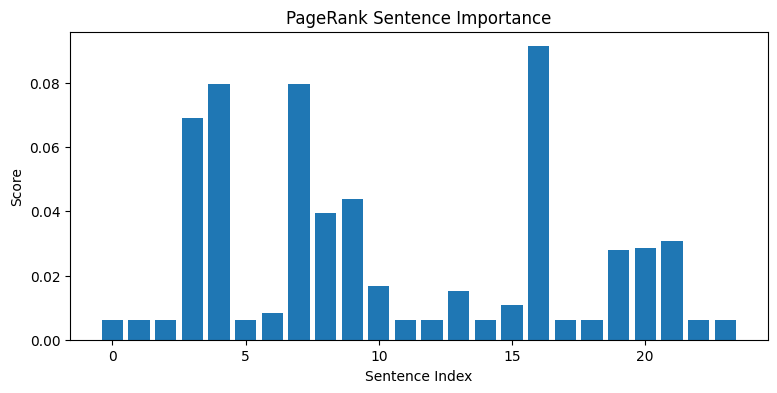

In [13]:
from summarize_cv import pagerank

if len(sentences) >= 2:
    scores = pagerank(sim_matrix)

    plt.figure(figsize=(9,4))
    plt.bar(range(len(scores)), scores)
    plt.title("PageRank Sentence Importance")
    plt.xlabel("Sentence Index")
    plt.ylabel("Score")
    plt.show()


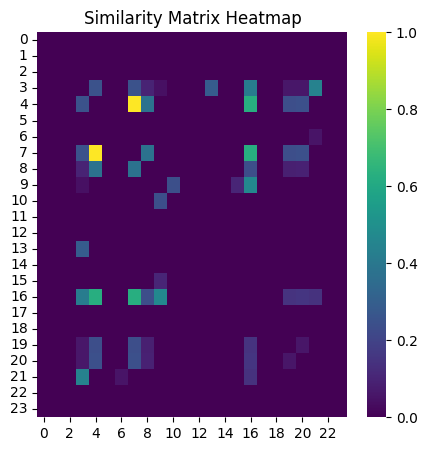

In [14]:
if len(sentences) >= 2:
    plt.figure(figsize=(5,5))
    sns.heatmap(sim_matrix, cmap="viridis", annot=False)
    plt.title("Similarity Matrix Heatmap")
    plt.show()
